# DUDE Document Understanding Dataset Benchmark Analysis

Executive Summary

**Dataset:** dude_mini - Document Understanding Dataset (DUDE)  
**Total Samples:** 404 document Q&A pairs per phase  
**Task:** Answer questions about complex, multi-page documents  
**Evaluation Metrics:** GT in Pred (PRIMARY), ANLS, Exact Match, Substring Match, Cosine Similarity

**Dataset Characteristics:**
- Complex document understanding with multi-page documents
- Requires reasoning across document layouts and structures
- Focuses on challenging real-world document scenarios
- Tests multi-page reasoning capabilities and structured document understanding

## QA Strategies

### $QA_{\text{OCR}}$: OCR parsing → LLM QA
Separate OCR extraction → LLM answers based on extracted text

### $QA_{\text{VLM-2stage}}$: VLM parsing → LLM QA  
Same VLM does both parsing and question answering

### $QA_{\text{VLM-direct}}$: Direct VLM QA
VLM sees image directly and answers question

## 1. Imports and Metadata

In [39]:
# Model ordering configuration for consistent display
MODEL_ORDER = ['azure_intelligence', 'mistral_document_ai', 'mistral_ocr_3', 'donut', 
               'gpt-5-nano', 'gpt-5-mini', 'claude_sonnet', 'claude_haiku']

def sort_models(models: List[str]) -> List[str]:
    """Sort models according to MODEL_ORDER."""
    def sort_key(model):
        # Extract base model name (remove __ suffix for QA1/QA2 phases)
        base_model = model.split('__')[-1] if '__' in model else model
        try:
            return MODEL_ORDER.index(base_model)
        except ValueError:
            return len(MODEL_ORDER)  # Unknown models go to the end
    return sorted(models, key=sort_key)

def get_model_display_name(model: str) -> str:
    """Get display name for model."""
    display_names = {
        'azure_intelligence': 'Azure Intelligence',
        'mistral_document_ai': 'Mistral OCR 2',
        'mistral_ocr_3': 'Mistral OCR 3',
        'donut': 'Donut',
        'gpt-5-nano': 'GPT-5 Nano',
        'gpt-5-mini': 'GPT-5 Mini',
        'claude_sonnet': 'Claude Sonnet',
        'claude_haiku': 'Claude Haiku'
    }
    # Handle composite model names (e.g., azure_intelligence__gpt-5-mini)
    if '__' in model:
        parts = model.split('__')
        return f"{display_names.get(parts[0], parts[0])} → {display_names.get(parts[1], parts[1])}"
    return display_names.get(model, model)


def get_phase_group(phase: str) -> str:
    """Get phase group with formal notation."""
    if phase.startswith('QA1'):
        return '$QA_{\\text{OCR}}$'
    elif phase.startswith('QA2'):
        return '$QA_{\\text{VLM-2stage}}$'
    elif phase.startswith('QA3'):
        return '$QA_{\\text{VLM-direct}}$'
    elif phase.startswith('QA4'):
        return '$QA_{\\text{special}}$'
    return 'Unknown'

def get_phase_formal_name(phase: str) -> str:
    """Get formal mathematical name for a specific phase."""
    phase_mapping = {
        'QA1a': '$QA_{\\text{OCR}}^{\\text{simple}}$',
        'QA1b': '$QA_{\\text{OCR}}^{\\text{generic}}$',
        'QA1c': '$QA_{\\text{OCR}}^{\\text{task-aware}}$',
        'QA2a': '$QA_{\\text{VLM-2stage}}^{\\text{cot}}$',
        'QA2b': '$QA_{\\text{VLM-2stage}}^{\\text{generic+cot}}$',
        'QA2c': '$QA_{\\text{VLM-2stage}}^{\\text{sonnet}}$',
        'QA3a': '$QA_{\\text{VLM-direct}}^{\\text{sonnet}}$',
        'QA3b': '$QA_{\\text{VLM-direct}}^{\\text{multi}}$',
    }
    return phase_mapping.get(phase, phase)

def get_phase_strategy(phase: str) -> str:
    """Alias for get_phase_group for consistency."""
    return get_phase_group(phase)

## 2. Dataset Explorer

Load all phase files and explore the DUDE dataset structure.

In [40]:
# Define paths
RESULTS_DIR = Path("../../2_clean/dude_mini")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - QA1a.csv
  - QA1b.csv
  - QA1c.csv
  - QA2a.csv
  - QA2b.csv
  - QA2c.csv
  - QA3a.csv
  - QA3b.csv


In [41]:
# Dataset configuration
DATASET_NAME = "dude_mini"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: dude_mini
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: QA2b, QA1c, QA1a, QA3b, QA3a, QA1b, QA2a, QA2c


In [42]:
# Load results for each phase
phase_dfs = {}

# Standard QA phases for DUDE (8 phases, no QA4)
STANDARD_PHASES = ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA2c', 'QA3a', 'QA3b']

for phase in STANDARD_PHASES:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

QA1a: 404 samples, 16 columns
QA1b: 404 samples, 16 columns
QA1c: 404 samples, 16 columns
QA2a: 404 samples, 8 columns
QA2b: 404 samples, 8 columns
QA2c: 404 samples, 14 columns
QA3a: 404 samples, 8 columns
QA3b: 404 samples, 8 columns

Total phases loaded: 8


In [43]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Question column: {'question' if 'question' in df.columns else 'NOT FOUND'}")
    print(f"  Ground truths column: {'ground_truths' if 'ground_truths' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


QA1a columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA1b columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA1c columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2a columns:
  Models: gpt-5-mini__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 8

QA2b columns:
  Models: gpt-5-mini__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 8

QA2c columns:
  Models: gpt-5-mini_gpt-5-mini, in_ground_truth_gpt-5-mini_gpt-5-mini
  Question column: question
  Ground truth

## 2.5 Data Quality Assessment ⚠️

**Critical Step:** Identify and filter out rows with empty predictions or errors to ensure accurate metrics.

In [44]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

DATA QUALITY ASSESSMENT

📊 QA1a - Total rows: 404
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)

📊 QA1b - Total rows: 404
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)

📊 QA1c - Total rows: 404
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)

📊 QA2a - Total rows: 404
  gpt-5-mini__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)

📊 QA2b - Total rows: 404
  gpt-5-mini__gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)

📊 QA2c - Total rows: 404
  gpt-5-mini_gpt-5-mini:
    ✅ Valid rows: 404/404 (100.0%)
  in_ground_truth_gpt-5-mini_

,Phase,Model,Total Rows,Valid Rows,Empty Predictions,Errors,Valid %
13,QA3a,gpt-5-mini,404,403,1,0,99.752475



⚠️  Found 1 model-phase combinations with data quality issues
These rows will be EXCLUDED from all metric calculations



## 3. Dataset Statistics

Analyze question and answer characteristics.

In [45]:
# Basic statistics for first available phase
phase_to_display = list(phase_dfs.keys())[0] if phase_dfs else None

if phase_to_display:
    print(f"\nBasic statistics for phase {phase_to_display}:")
    df_base = phase_dfs[phase_to_display]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'question' in df_base.columns:
        # Question length statistics
        question_lengths = df_base['question'].astype(str).str.len()
        question_word_counts = df_base['question'].astype(str).str.split().str.len()
        
        print(f"\nQuestion Length (characters):")
        print(f"  Mean: {question_lengths.mean():.1f} characters")
        print(f"  Median: {question_lengths.median():.1f} characters")
        print(f"  Min: {question_lengths.min()} characters")
        print(f"  Max: {question_lengths.max()} characters")
        
        print(f"\nQuestion Length (words):")
        print(f"  Mean: {question_word_counts.mean():.1f} words")
        print(f"  Median: {question_word_counts.median():.1f} words")
        
    if 'ground_truths' in df_base.columns:
        # Answer length statistics
        df_base['parsed_gt'] = df_base['ground_truths'].apply(parse_ground_truths)
        df_base['num_ground_truths'] = df_base['parsed_gt'].apply(len)
        df_base['avg_answer_length'] = df_base['parsed_gt'].apply(
            lambda gts: np.mean([len(str(gt)) for gt in gts]) if gts else 0
        )
        
        print(f"\nGround Truth Answer Statistics:")
        print(f"  Mean answers per question: {df_base['num_ground_truths'].mean():.2f}")
        print(f"  Median answers per question: {df_base['num_ground_truths'].median():.0f}")
        print(f"  Max answers for a single question: {df_base['num_ground_truths'].max():.0f}")
        
        print(f"\nAverage Answer Length (characters):")
        print(f"  Mean: {df_base['avg_answer_length'].mean():.1f} characters")
        print(f"  Median: {df_base['avg_answer_length'].median():.1f} characters")
        print(f"  Min: {df_base['avg_answer_length'].min():.1f} characters")
        print(f"  Max: {df_base['avg_answer_length'].max():.1f} characters")


Basic statistics for phase QA1a:
Dataset Statistics:
  Total samples: 404

Question Length (characters):
  Mean: 48.3 characters
  Median: 44.0 characters
  Min: 12 characters
  Max: 164 characters

Question Length (words):
  Mean: 9.0 words
  Median: 8.0 words

Ground Truth Answer Statistics:
  Mean answers per question: 1.08
  Median answers per question: 1
  Max answers for a single question: 6

Average Answer Length (characters):
  Mean: 18.0 characters
  Median: 11.0 characters
  Min: 0.0 characters
  Max: 217.0 characters


## 4. Sample Preview

Display 10 random Q&A samples from the first available model.

### Metric Definitions:
- **GT in Pred (Ground Truth in Prediction)** [PRIMARY]: Whether the ground truth answer appears as a substring in the model's prediction. Score 1.0 if found, 0.0 otherwise.
- **ANLS (Average Normalized Levenshtein Similarity)**: Measures character-level similarity between prediction and ground truth using Levenshtein distance, normalized to 0-1 scale.
- **Cosine Similarity**: Semantic similarity between prediction and ground truth using embedding vectors. Measures meaning similarity regardless of exact wording.
- **Exact Match**: Binary score (0 or 1) indicating whether prediction exactly matches ground truth (case-insensitive).
- **Substring Match**: Binary score (0 or 1) indicating whether ground truth appears anywhere as a substring in the prediction.

### Understanding Substring Match:
**Substring Match** checks if the ground truth answer appears *anywhere* in the model's prediction as consecutive characters. It is useful for extractive QA tasks where the expected answer is a direct excerpt from the source material.

**Examples:**
- Prediction: "The answer is Paris, which is the capital of France"
  - Ground Truth: "Paris"
  - Substring Match: 1.0 ✓ (found "Paris" consecutively in prediction)

- Prediction: "The capital is in the city of Paris in France"
  - Ground Truth: "Paris"
  - Substring Match: 1.0 ✓ (still found "Paris" as consecutive characters)

- Prediction: "The capital is P-a-r-i-s with an Eiffel tower"
  - Ground Truth: "Paris"
  - Substring Match: 0.0 ✗ (letters are separated, not consecutive)

- Prediction: "The French capital starts with P and ends with S"
  - Ground Truth: "Paris"
  - Substring Match: 0.0 ✗ (individual characters present but not as substring)

## 5. Metrics Calculation

Calculate GT in Pred, ANLS, EM, Substring Match, and Cosine Similarity for all models across all samples.

In [46]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

# Function to calculate QA metrics for a single prediction
def calculate_qa_metrics(
    prediction: str,
    ground_truths: List[str],
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager,
    parsed_data: str = None
) -> Dict[str, float]:
    """Calculate all QA metrics for a single sample with cached embeddings."""
    if pd.isna(prediction) or prediction == "" or not ground_truths:
        return {
            'gt_in_pred': 0.0,  # PRIMARY METRIC FIRST
            'anls': 0.0,
            'exact_match': 0.0,
            'substring_match': 0.0,
            'pred_in_gt': 0.0,
            'cosine_similarity': 0.0,
            'gt_in_parsed': 0.0,
        }
    
    pred_str = str(prediction)
    
    # Compute cosine similarity with first ground truth
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=ground_truths[0],
        prediction=pred_str,
        sample_id=sample_id,
        model=model
    )
    
    # Check if ground truth appears in parsed data
    gt_in_parsed = 0.0
    if parsed_data:
        parsed_str = str(parsed_data).lower()
        for gt in ground_truths:
            if gt.lower() in parsed_str:
                gt_in_parsed = 1.0
                break
    
    return {
        'gt_in_pred': compute_ground_truth_in_prediction(pred_str, ground_truths),  # PRIMARY METRIC FIRST
        'anls': compute_anls(pred_str, ground_truths, threshold=0.5),
        'exact_match': compute_exact_match(pred_str, ground_truths),
        'substring_match': compute_substring_match(pred_str, ground_truths),
        'pred_in_gt': compute_prediction_in_ground_truth(pred_str, ground_truths),
        'cosine_similarity': cosine_sim,
        'gt_in_parsed': gt_in_parsed,
    }

# Calculate metrics for all phases and models

## 6. Metrics Summary Table

Aggregate view of all metrics across phases and models.

In [47]:
# Create a summary DataFrame
summary_data = []

for strategy, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': strategy,
            'Model': model,
            'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC FIRST
            'ANLS': metrics['anls'],
            'Exact Match': metrics['exact_match'],
            'Substring Match': metrics['substring_match'],
            'Pred in GT': metrics['pred_in_gt'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'GT in Parsed Data': metrics.get('gt_in_parsed', 0.0),
            'Valid Samples': metrics['valid_samples'],
            'Total Samples': metrics['total_samples']
        })

summary_df = pd.DataFrame(summary_data)
summary_df['Strategy'] = summary_df['Phase'].apply(get_phase_strategy)


print("\n🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)")
print("=" * 150)
print("\nMetrics Summary (sorted by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
display(summary_df.sort_values(['Phase', 'GT in Pred'], ascending=[True, False]))

# Best model per strategy (by GT in Pred - PRIMARY METRIC)
print("\n" + "=" * 150)
print("🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    best_model = strategy_data.loc[strategy_data['GT in Pred'].idxmax()]
    print(f"  {strategy}: {get_model_display_name(best_model['Model'])}")
    print(f"    🎯 GT in Pred: {best_model['GT in Pred']:.4f} [PRIMARY]")
    print(f"       ANLS: {best_model['ANLS']:.4f}, EM: {best_model['Exact Match']:.4f}")
    print(f"       Valid samples: {best_model['Valid Samples']}/{best_model['Total Samples']}")

print("\n" + "=" * 150)



🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)

Metrics Summary (sorted by GT in Pred - PRIMARY METRIC):


,Phase,Model,GT in Pred,ANLS,Exact Match,Substring Match,Pred in GT,Cosine Similarity,GT in Parsed Data,Valid Samples,Total Samples,Strategy
0,QA1a,azure_intelligence__gpt-5-mini,0.517327,0.355502,0.205446,0.544554,0.232673,0.596060,0.0,404,404,$QA_{\text{OCR}}$
2,QA1a,mistral_ocr_3__gpt-5-mini,0.507426,0.341063,0.195545,0.524752,0.212871,0.589810,0.0,404,404,$QA_{\text{OCR}}$
1,QA1a,mistral_document_ai__gpt-5-mini,0.500000,0.344145,0.195545,0.524752,0.220297,0.592024,0.0,404,404,$QA_{\text{OCR}}$
3,QA1b,azure_intelligence__gpt-5-mini,0.470297,0.502579,0.353960,0.514851,0.398515,0.630018,0.0,404,404,$QA_{\text{OCR}}$
4,QA1b,mistral_document_ai__gpt-5-mini,0.470297,0.511957,0.361386,0.519802,0.410891,0.633890,0.0,404,404,$QA_{\text{OCR}}$
5,QA1b,mistral_ocr_3__gpt-5-mini,0.462871,0.503019,0.349010,0.507426,0.393564,0.633529,0.0,404,404,$QA_{\text{OCR}}$
8,QA1c,mistral_ocr_3__gpt-5-mini,0.574257,0.000000,0.000000,0.574257,0.000000,0.385435,0.0,404,404,$QA_{\text{OCR}}$
6,QA1c,azure_intelligence__gpt-5-mini,0.561881,0.000000,0.000000,0.561881,0.000000,0.381792,0.0,404,404,$QA_{\text{OCR}}$
7,QA1c,mistral_document_ai__gpt-5-mini,0.561881,0.003540,0.000000,0.561881,0.000000,0.386095,0.0,404,404,$QA_{\text{OCR}}$
9,QA2a,gpt-5-mini__gpt-5-mini,0.487624,0.345051,0.180693,0.514851,0.207921,0.582341,0.0,404,404,$QA_{\text{VLM-2stage}}$



🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):
  $QA_{\text{OCR}}$: Mistral OCR 3 → GPT-5 Mini
    🎯 GT in Pred: 0.5743 [PRIMARY]
       ANLS: 0.0000, EM: 0.0000
       Valid samples: 404/404
  $QA_{\text{VLM-2stage}}$: gpt-5-mini_gpt-5-mini
    🎯 GT in Pred: 0.5545 [PRIMARY]
       ANLS: 0.0000, EM: 0.0000
       Valid samples: 404/404
  $QA_{\text{VLM-direct}}$: GPT-5 Mini
    🎯 GT in Pred: 0.4975 [PRIMARY]
       ANLS: 0.3906, EM: 0.2302
       Valid samples: 404/404



In [48]:
# Display 10 random samples with metrics
if len(phase_dfs) > 0:
    # Use first available phase
    display_phase = list(phase_dfs.keys())[0]
    df_display = phase_dfs[display_phase].copy()
    
    # Get first model for sample display
    pred_cols = [col for col in df_display.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    pred_col = pred_cols[0]
    err_col = f'error_{first_model}'
    
    # Filter to valid rows only
    valid_rows = []
    for idx, row in df_display.iterrows():
        if is_valid_row(row, pred_col, err_col):
            valid_rows.append((idx, row))
    
    if len(valid_rows) > 0:
        # Randomly select 10 samples
        import random
        sample_indices = random.sample(range(len(valid_rows)), min(10, len(valid_rows)))
        
        print(f"\n📋 Random Sample Preview ({get_model_display_name(first_model)}) - Phase {display_phase}")
        print("=" * 100)
        
        for sample_num, idx_in_valid in enumerate(sample_indices, 1):
            _, row = valid_rows[idx_in_valid]
            
            # Get ground truths
            ground_truths = parse_ground_truths(row['ground_truths'])
            gt_text = ground_truths[0] if ground_truths else "N/A"
            
            # Calculate metrics using the full metrics function
            prediction = str(row[pred_col])
            metrics = calculate_qa_metrics(
                prediction=prediction,
                ground_truths=ground_truths,
                phase=display_phase,
                sample_id=row['sample_id'],
                model=first_model,
                emb_manager=embedding_manager
            )
            
            # Print sample in requested format
            print(f"\nSample {sample_num}: GT_in_pred: {metrics['gt_in_pred']:.4f}, ANLS: {metrics['anls']:.4f}")
            print(f"Cosine Similarity: {metrics['cosine_similarity']:.4f}")
            print(f"Exact Match: {metrics['exact_match']:.4f}")
            print(f"Substring Match: {metrics['substring_match']:.4f}")
            print(f"Prediction: {prediction}")
            print(f"Ground truth: {gt_text}")
        
        print("\n" + "=" * 100)


📋 Random Sample Preview (Azure Intelligence → GPT-5 Mini) - Phase QA1a

Sample 1: GT_in_pred: 0.0000, ANLS: 0.0000
Cosine Similarity: 0.5597
Exact Match: 0.0000
Substring Match: 0.0000
Prediction: The individuals' nationalities (e.g., Lebanese, Syrian, Filipino, Egyptian).
Ground truth: Nationality

Sample 2: GT_in_pred: 1.0000, ANLS: 0.0000
Cosine Similarity: 0.2895
Exact Match: 0.0000
Substring Match: 1.0000
Prediction: The rated power is 1800 watts.
Ground truth: 1800

Sample 3: GT_in_pred: 0.0000, ANLS: 0.9091
Cosine Similarity: 0.9592
Exact Match: 0.0000
Substring Match: 0.0000
Prediction: 18.15–19.15
Ground truth: 18.15-19.15

Sample 4: GT_in_pred: 0.0000, ANLS: 0.0000
Cosine Similarity: 0.0976
Exact Match: 0.0000
Substring Match: 0.0000
Prediction: I can't tell from this document — it doesn't show any marital status.
Ground truth: yes

Sample 5: GT_in_pred: 1.0000, ANLS: 0.0000
Cosine Similarity: 0.1190
Exact Match: 0.0000
Substring Match: 1.0000
Prediction: I can’t read questi

In [49]:
# Display 10 random samples with metrics
if len(phase_dfs) > 0:
    # Use first available phase
    display_phase = list(phase_dfs.keys())[0]
    df_display = phase_dfs[display_phase].copy()
    
    # Get first model for sample display
    pred_cols = [col for col in df_display.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    pred_col = pred_cols[0]
    err_col = f'error_{first_model}'
    
    # Filter to valid rows only
    valid_rows = []
    for idx, row in df_display.iterrows():
        if is_valid_row(row, pred_col, err_col):
            valid_rows.append((idx, row))
    
    if len(valid_rows) > 0:
        # Randomly select 10 samples
        import random
        sample_indices = random.sample(range(len(valid_rows)), min(10, len(valid_rows)))
        
        print(f"\n📋 Random Sample Preview ({get_model_display_name(first_model)}) - Phase {display_phase}")
        print("=" * 100)
        
        for sample_num, idx_in_valid in enumerate(sample_indices, 1):
            _, row = valid_rows[idx_in_valid]
            
            # Get ground truths
            ground_truths = parse_ground_truths(row['ground_truths'])
            gt_text = ground_truths[0] if ground_truths else "N/A"
            
            # Calculate metrics
            prediction = str(row[pred_col])
            metrics = calculate_qa_metrics(
                prediction=prediction,
                ground_truths=ground_truths,
                phase=display_phase,
                sample_id=row['sample_id'],
                model=first_model,
                emb_manager=embedding_manager
            )
            
            # Print sample in requested format
            print(f"Sample {sample_num}: GT_in_pred: {metrics['gt_in_pred']:.4f}, ANLS: {metrics['anls']:.4f}")
            print(f"Cosine Similarity: {metrics['cosine_similarity']:.4f}")
            print(f"Exact Match: {metrics['exact_match']:.4f}")
            print(f"Substring Match: {metrics['substring_match']:.4f}")
            print(f"Prediction: {prediction}")
            print(f"Ground truth: {gt_text}")
            print()
        
        print("=" * 100)


📋 Random Sample Preview (Azure Intelligence → GPT-5 Mini) - Phase QA1a


Identical embeddings for sample 62936734856bf9935afacb0b066fd55c_f81ef8b44228669c3fe13c061594d55c, model azure_intelligence__gpt-5-mini


Sample 1: GT_in_pred: 0.0000, ANLS: 0.0000
Cosine Similarity: 0.6999
Exact Match: 0.0000
Substring Match: 0.0000
Prediction: Wiki Loves Monuments
Ground truth: https://commons.wikimedia.org/wiki/Wiki_Loves_Monuments_2014_winners

Sample 2: GT_in_pred: 0.0000, ANLS: 0.0000
Cosine Similarity: 0.3278
Exact Match: 0.0000
Substring Match: 0.0000
Prediction: The visible page does not say where to get Nomination forms for the Outstanding Teacher Award. That information appears to be on page 2 (the articles here say “please turn to p. 2”). Please provide page 2 or the portion of the document that mentions the award and I’ll extract the locations for you.
Ground truth: ['College Alumni Union Desk ', " Dean's offices ", ' February 4th issue of the faculty Council Newsletter, The Forum']

Sample 3: GT_in_pred: 1.0000, ANLS: 1.0000
Cosine Similarity: 1.0000
Exact Match: 1.0000
Substring Match: 1.0000
Prediction: Tammy L. Brunner
Ground truth: Tammy L. Brunner

Sample 4: GT_in_pred: 1.0000, ANLS: 1

## 7. Visualizations - Bar Charts

Compare all metrics across models and phases.

In [50]:
# Bar charts for each metric (PRIMARY METRIC FIRST), organized by strategy
strategies = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']
metrics_to_plot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']

for strategy in strategies:
    # Filter summary_df for this strategy
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    if strategy_data.empty:
        continue
    
    fig, axes = plt.subplots(2, 3, figsize=(24, 14))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        # Pivot data for this metric
        pivot_data = strategy_data.pivot_table(
            index='Model', 
            columns='Phase', 
            values=metric, 
            aggfunc='mean'
        )
        
        # Sort models
        pivot_data = pivot_data.reindex(sort_models(pivot_data.index.tolist()))
        
        pivot_data.plot(kind='bar', ax=ax, color=colors_palette[:len(pivot_data.columns)], 
                       alpha=0.85, width=0.8)
        
        # Emphasize primary metric
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        title_suffix = " [PRIMARY METRIC]" if metric == 'GT in Pred' else ""
        
        ax.set_title(f'{title_prefix}{metric} by Model{title_suffix}',
                     fontsize=15 if metric == 'GT in Pred' else 14,
                     fontweight='bold', pad=15)
        ax.set_xlabel('Model', fontsize=13)
        ax.set_ylabel(metric, fontsize=13)
        ax.legend(title='Phase', title_fontsize=12, fontsize=10, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_xticklabels([get_model_display_name(m) for m in pivot_data.index], 
                           rotation=45, ha='right')
        ax.set_ylim(0, 1.05)
        
        # Add value labels on bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
    
    # Hide last subplot if not needed
    if len(metrics_to_plot) < 6:
        axes[-1].set_visible(False)
    
    fig.suptitle(f'{strategy} - Metrics by Model and Phase', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric")


🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric


## 8. Visualizations - Box Plots

Distribution analysis showing variance and outliers.

In [51]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

print("Calculating per-sample metrics for box plots (using only valid rows)...")
for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in tqdm(pred_cols, desc=f"Strategy {phase}", leave=False):
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        for _, row in df.iterrows():
            if not is_valid_row(row, pred_col, err_col):
                continue  # Skip invalid rows
            
            ground_truths = parse_ground_truths(row['ground_truths'])
            metrics = calculate_qa_metrics(
                row[pred_col], ground_truths, phase, 
                row['sample_id'], model, embedding_manager
            )
            
            sample_metrics_data.append({
                'Strategy': phase,
                'Model': model,
                'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC
                'ANLS': metrics['anls'],
                'Exact Match': metrics['exact_match'],
                'Substring Match': metrics['substring_match'],
                'Cosine Similarity': metrics['cosine_similarity']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Separate figures for QA1, QA2, and QA3
strategies = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']
metrics_for_boxplot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']

for strategy in strategies:
    strategy_data = sample_metrics_df[sample_metrics_df['Strategy'].apply(get_phase_strategy) == strategy]
    if strategy_data.empty:
        continue
    
    fig, axes = plt.subplots(2, 3, figsize=(24, 14))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics_for_boxplot):
        ax = axes[idx]
        
        # Create box plot
        strategy_data_sorted = strategy_data.copy()
        strategy_data_sorted['Model'] = pd.Categorical(
            strategy_data_sorted['Model'],
            categories=sort_models(strategy_data_sorted['Model'].unique().tolist()),
            ordered=True
        )
        
        sns.boxplot(data=strategy_data_sorted, x='Model', y=metric, ax=ax)
        
        # Emphasize primary metric
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric} Distribution - {strategy}', 
                    fontsize=15 if metric == 'GT in Pred' else 14, 
                    fontweight='bold', pad=15)
        ax.set_xlabel('Model', fontsize=13)
        ax.set_ylabel(metric, fontsize=13)
        ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Hide last subplot if not needed
    if len(metrics_for_boxplot) < 6:
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: Distributions show only valid samples (empty/error rows excluded)")

Calculating per-sample metrics for box plots (using only valid rows)...


Strategy QA1a:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample 06cc755612621483103dd1752c3927f7_20bc915e220e460a539fb622f1085943, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 098bda18540fa5e097196c3f7898d4f1_c55543406c7e546faafb9246d0fff991, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_a19fd127268fb9493257f12d53d5d53d, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_c765b29277f8fc85f08f4560a244f5ea, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0e22690bb0a737fae78b1f8c6fc0dede_627dff624e1cf732f3cc27a7edfc3ddc, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 20d4e677f9352bf26955132c1c565224_d0fc0282ab9a26f31092bb8bcc1a0e35, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 219acc43859e61b1a16d9e52a42e7216_136cbfbd28f461b0057dd17b76d99409, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 28a3508ea6ad3b25

Strategy QA1b:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample 001d6f557c342ef5a67cd38a29da9e83_6d7cc36223d7bf354edc3eeff4ad0577, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 03b0ce944fb20ef2d3bd350d172344f4_e229289181e94b5c9e04f541ceb3c20a, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 06cc755612621483103dd1752c3927f7_6489017023d8d62731ca8126007cd05b, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 06cc755612621483103dd1752c3927f7_ae4b30f6e44a34292d572b1931c4b8ac, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 098bda18540fa5e097196c3f7898d4f1_9f4da5b4e842a55980e06bab593c39e1, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_38e51a2f72a54368fa57c921916f7cba, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_a19fd127268fb9493257f12d53d5d53d, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 0afbb63ded89d333

...

Strategy QA3a:   0%|          | 0/1 [00:00<?, ?it/s]

Identical embeddings for sample 06cc755612621483103dd1752c3927f7_6489017023d8d62731ca8126007cd05b, model gpt-5-mini
Identical embeddings for sample 09a039762a17ef85fbe52be984e62740_c8ffa164c8f890a16b521db4c37453fa, model gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_a19fd127268fb9493257f12d53d5d53d, model gpt-5-mini
Identical embeddings for sample 0afbb63ded89d3335a5109f8a9ec4db7_c765b29277f8fc85f08f4560a244f5ea, model gpt-5-mini
Identical embeddings for sample 0ce23d1b787bf894de339a4dae34f5f4_13fa01a95a4c198477e1a89d186a67a4, model gpt-5-mini
Identical embeddings for sample 20d4e677f9352bf26955132c1c565224_0080660a09ef69357e81ad256a3df234, model gpt-5-mini
Identical embeddings for sample 20d4e677f9352bf26955132c1c565224_d0fc0282ab9a26f31092bb8bcc1a0e35, model gpt-5-mini
Identical embeddings for sample 219acc43859e61b1a16d9e52a42e7216_136cbfbd28f461b0057dd17b76d99409, model gpt-5-mini
Identical embeddings for sample 2369d6d8c2d8a3bc6efb871d1325c411_3db1ebd

Strategy QA3b:   0%|          | 0/1 [00:00<?, ?it/s]

Identical embeddings for sample 001d6f557c342ef5a67cd38a29da9e83_6d7cc36223d7bf354edc3eeff4ad0577, model gpt-5-mini
Identical embeddings for sample 06cc755612621483103dd1752c3927f7_ae4b30f6e44a34292d572b1931c4b8ac, model gpt-5-mini
Identical embeddings for sample 0ce23d1b787bf894de339a4dae34f5f4_13fa01a95a4c198477e1a89d186a67a4, model gpt-5-mini
Identical embeddings for sample 0e22690bb0a737fae78b1f8c6fc0dede_627dff624e1cf732f3cc27a7edfc3ddc, model gpt-5-mini
Identical embeddings for sample 11ef3f295ed60f2d864f3028754e11c3_ca3d1b507a59189ffe4cd45c4e01fa85, model gpt-5-mini
Identical embeddings for sample 20d4e677f9352bf26955132c1c565224_d0fc0282ab9a26f31092bb8bcc1a0e35, model gpt-5-mini
Identical embeddings for sample 219acc43859e61b1a16d9e52a42e7216_136cbfbd28f461b0057dd17b76d99409, model gpt-5-mini
Identical embeddings for sample 2369d6d8c2d8a3bc6efb871d1325c411_3db1ebd7635421d9c8cf7a947eccab03, model gpt-5-mini
Identical embeddings for sample 2f430bfa8fcbc42ca17a31234fda3842_1e6c0ee


🎯 Note: Distributions show only valid samples (empty/error rows excluded)


## 9. Visualizations - Heatmaps

Model × Phase performance heatmaps.


Heatmaps for QA1 (OCR+VLM)

GT in Pred Table for QA1 (OCR+VLM):


,QA1a,QA1b,QA1c
Mistral OCR 3 → GPT-5 Mini,0.507426,0.462871,0.574257
Azure Intelligence → GPT-5 Mini,0.517327,0.470297,0.561881
Mistral OCR 2 → GPT-5 Mini,0.500000,0.470297,0.561881



ANLS Table for QA1 (OCR+VLM):


,QA1a,QA1b,QA1c
Mistral OCR 3 → GPT-5 Mini,0.341063,0.503019,0.00000
Azure Intelligence → GPT-5 Mini,0.355502,0.502579,0.00000
Mistral OCR 2 → GPT-5 Mini,0.344145,0.511957,0.00354



Exact Match Table for QA1 (OCR+VLM):


,QA1a,QA1b,QA1c
Mistral OCR 3 → GPT-5 Mini,0.195545,0.349010,0.0
Azure Intelligence → GPT-5 Mini,0.205446,0.353960,0.0
Mistral OCR 2 → GPT-5 Mini,0.195545,0.361386,0.0



Cosine Similarity Table for QA1 (OCR+VLM):


,QA1a,QA1b,QA1c
Mistral OCR 3 → GPT-5 Mini,0.589810,0.633529,0.385435
Azure Intelligence → GPT-5 Mini,0.596060,0.630018,0.381792
Mistral OCR 2 → GPT-5 Mini,0.592024,0.633890,0.386095


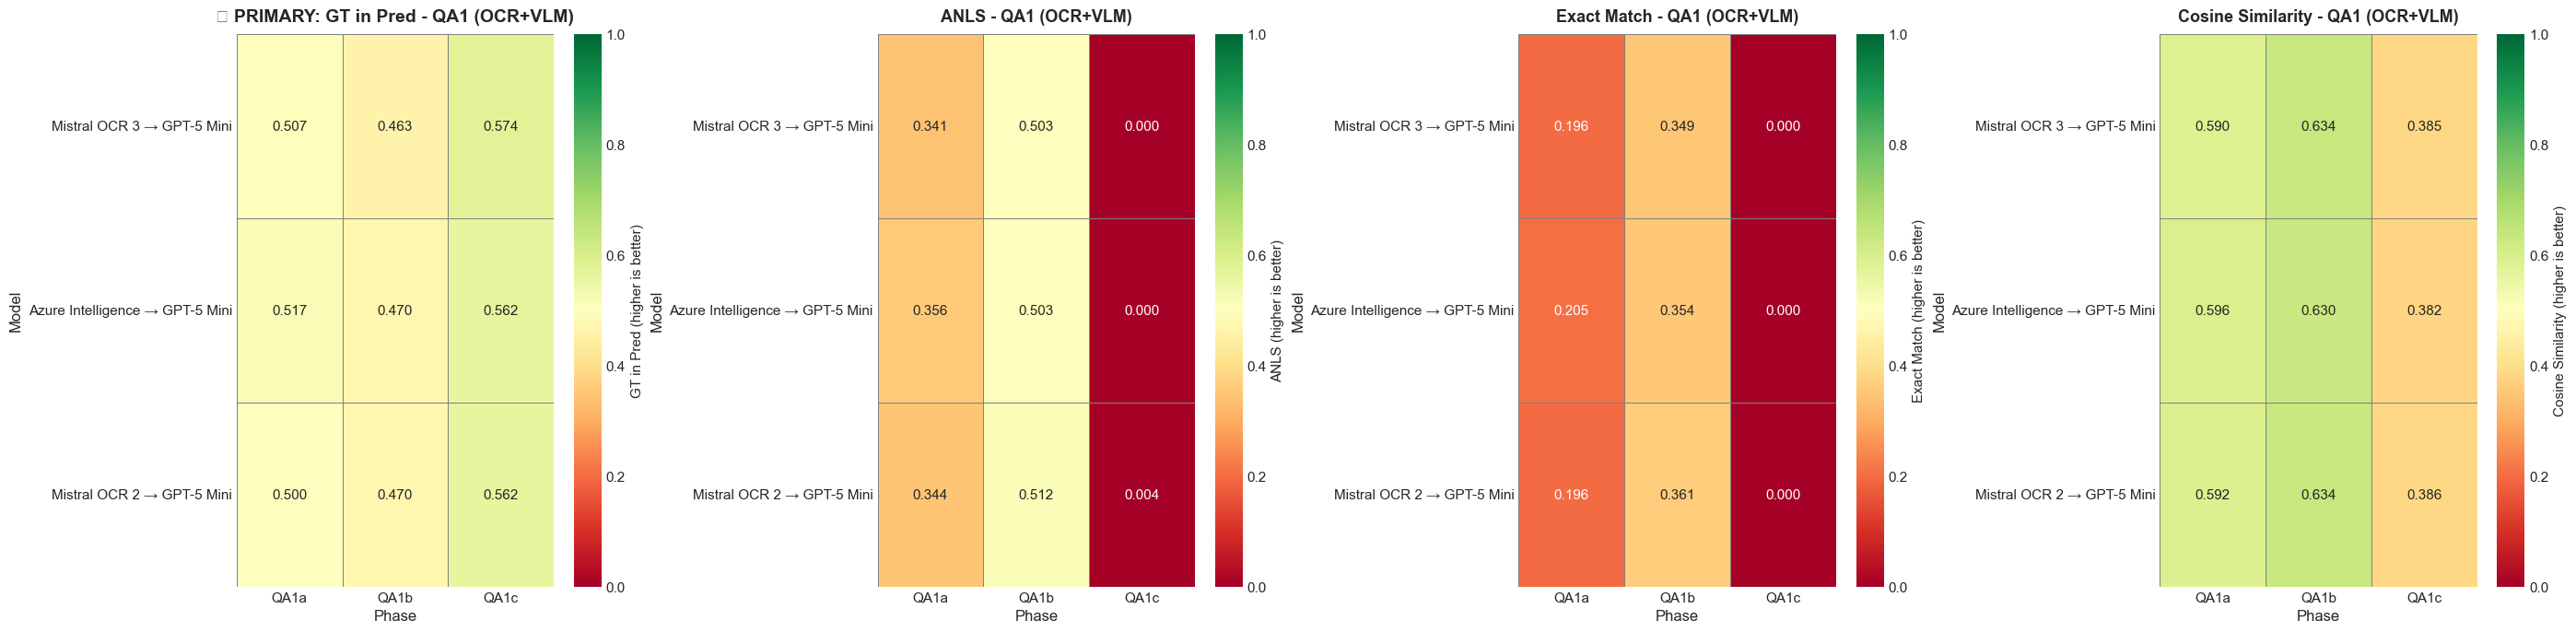


Heatmaps for QA2 (VLM Parse+QA)

GT in Pred Table for QA2 (VLM Parse+QA):


,QA2a,QA2b,QA2c
GPT-5 Mini → GPT-5 Mini,0.487624,0.443069,NaN
gpt-5-mini_gpt-5-mini,NaN,NaN,0.554455
in_ground_truth_gpt-5-mini_gpt-5-mini,NaN,NaN,0.000000



ANLS Table for QA2 (VLM Parse+QA):


,QA2a,QA2b,QA2c
GPT-5 Mini → GPT-5 Mini,0.345051,0.504928,NaN
gpt-5-mini_gpt-5-mini,NaN,NaN,0.000000
in_ground_truth_gpt-5-mini_gpt-5-mini,NaN,NaN,0.002888



Exact Match Table for QA2 (VLM Parse+QA):


,QA2a,QA2b,QA2c
GPT-5 Mini → GPT-5 Mini,0.180693,0.334158,NaN
gpt-5-mini_gpt-5-mini,NaN,NaN,0.0
in_ground_truth_gpt-5-mini_gpt-5-mini,NaN,NaN,0.0



Cosine Similarity Table for QA2 (VLM Parse+QA):


,QA2a,QA2b,QA2c
GPT-5 Mini → GPT-5 Mini,0.582341,0.630575,NaN
gpt-5-mini_gpt-5-mini,NaN,NaN,0.380531
in_ground_truth_gpt-5-mini_gpt-5-mini,NaN,NaN,0.209485


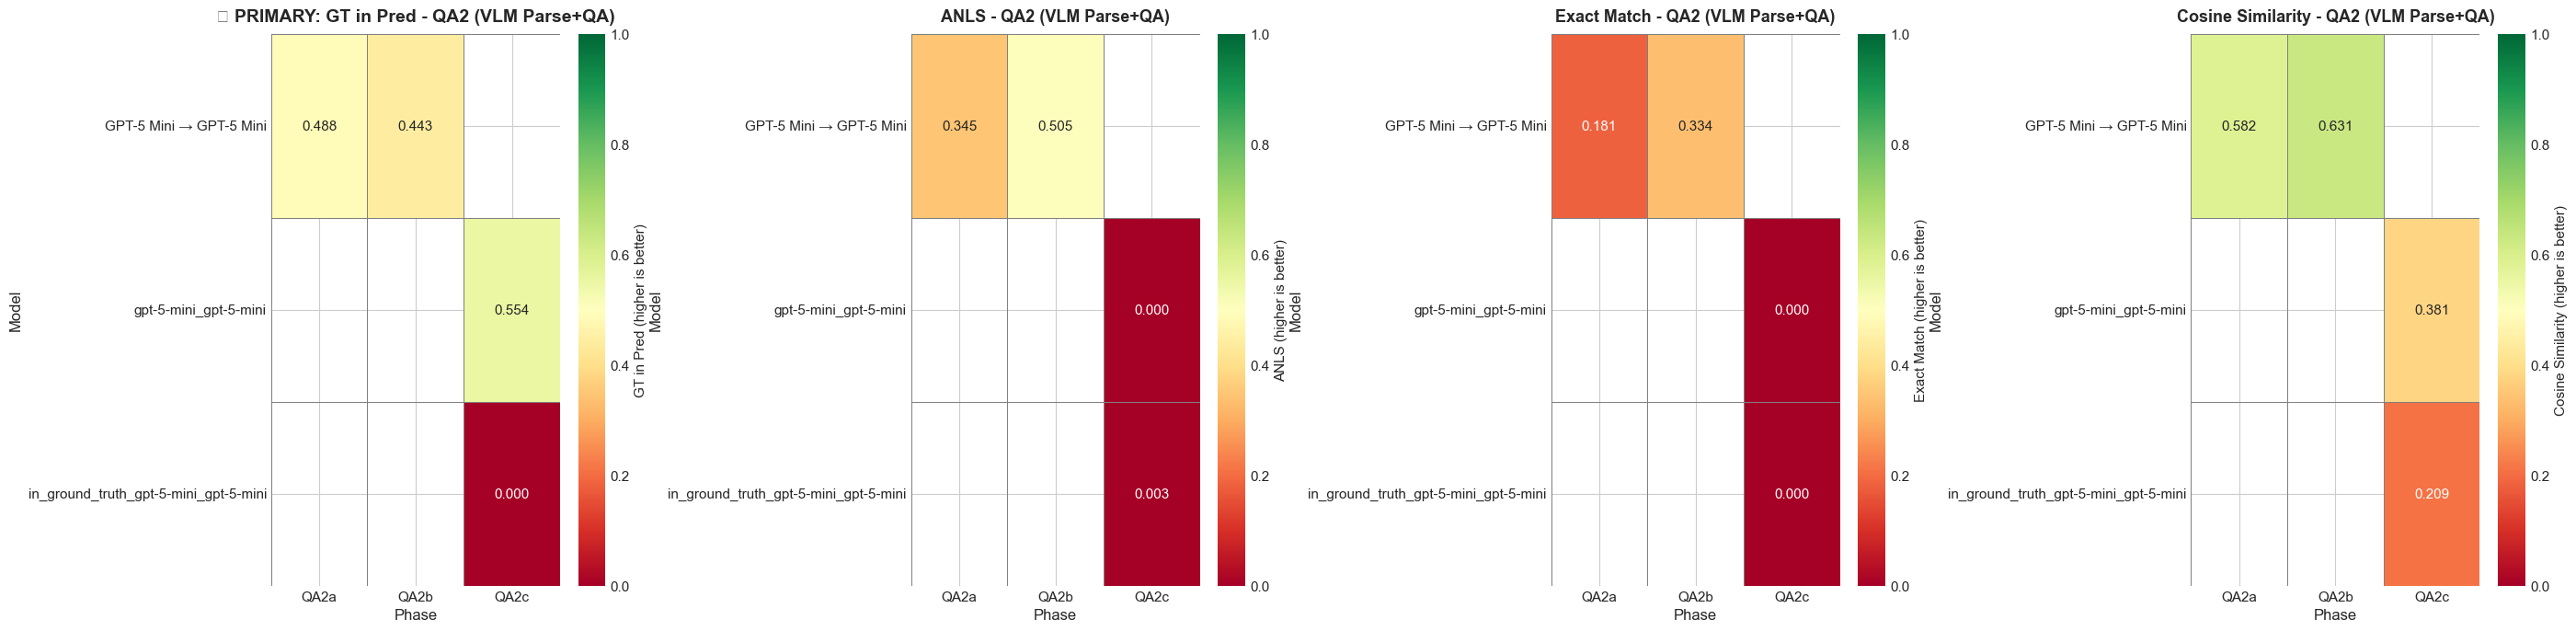


Heatmaps for QA3 (Direct VQA)

GT in Pred Table for QA3 (Direct VQA):


,QA3a,QA3b
GPT-5 Mini,0.488834,0.497525



ANLS Table for QA3 (Direct VQA):


,QA3a,QA3b
GPT-5 Mini,0.363116,0.390613



Exact Match Table for QA3 (Direct VQA):


,QA3a,QA3b
GPT-5 Mini,0.208437,0.230198



Cosine Similarity Table for QA3 (Direct VQA):


,QA3a,QA3b
GPT-5 Mini,0.602858,0.588953


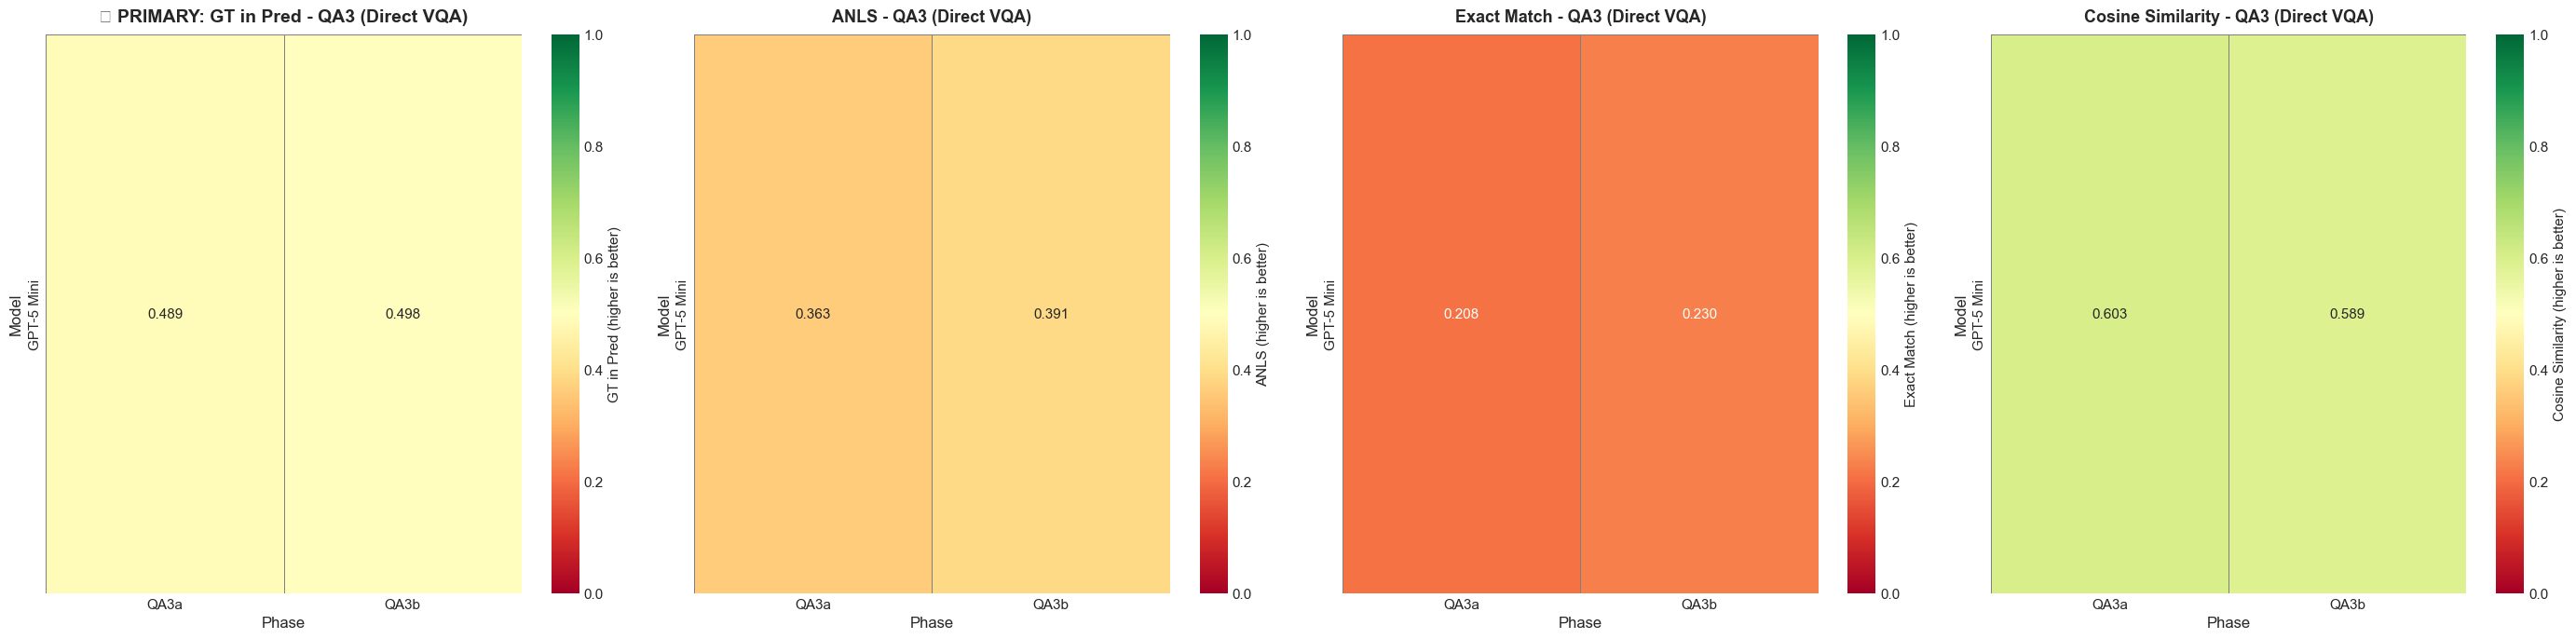


🎯 Note: 'GT in Pred' heatmaps show PRIMARY metric performance


In [52]:
# Create heatmaps for key metrics (PRIMARY METRIC FIRST), separated by strategy
# print these as tables as well
metrics_to_show = ['GT in Pred', 'ANLS', 'Exact Match', 'Cosine Similarity']

# Define strategies and their phases
strategy_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

for strategy_name, phases in strategy_groups.items():
    print(f"\n{'='*80}")
    print(f"Heatmaps for {strategy_name}")
    print(f"{'='*80}")
    
    # Filter phases for this strategy - check which ones are in metrics_results
    strategy_phase_names = [p for p in phases if p in metrics_results]
    if not strategy_phase_names:
        print(f"⚠️ No phases found for {strategy_name}")
        continue
    
    fig, axes = plt.subplots(1, len(metrics_to_show), figsize=(7 * len(metrics_to_show), 7))
    
    if len(metrics_to_show) == 1:
        axes = [axes]
    
    for idx, metric_name in enumerate(metrics_to_show):
        ax = axes[idx]
        
        # Create heatmap data: rows = models, columns = phases in this strategy
        heatmap_data = []
        model_names = []
        
        # Get all unique models across the phases in this strategy
        all_models = set()
        for phase in strategy_phase_names:
            if phase in metrics_results:
                all_models.update(metrics_results[phase].keys())
        all_models = sort_models(list(all_models))
        
        # Build heatmap data
        for model in all_models:
            row_data = []
            for phase in strategy_phase_names:
                if phase in metrics_results and model in metrics_results[phase]:
                    # Map metric name to key
                    metric_key = metric_name.lower().replace(' ', '_')
                    value = metrics_results[phase][model].get(metric_key, np.nan)
                    row_data.append(value)
                else:
                    row_data.append(np.nan)
            
            heatmap_data.append(row_data)
            model_names.append(model)
        
        heatmap_df = pd.DataFrame(
            heatmap_data,
            index=[get_model_display_name(m) for m in model_names],
            columns=strategy_phase_names
        )
        
        # Print the table
        print(f"\n{metric_name} Table for {strategy_name}:")
        display(heatmap_df)
        
        # Use colormap: green for good, red for bad (all QA metrics: higher is better)
        cmap = 'RdYlGn'
        cbar_label = f'{metric_name} (higher is better)'
        
        sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                    ax=ax, cbar_kws={'label': cbar_label}, 
                    vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
        
        # Emphasize primary metric in title
        title_prefix = "🎯 PRIMARY: " if metric_name == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric_name} - {strategy_name}', 
                    fontsize=14 if metric_name == 'GT in Pred' else 13, 
                    fontweight='bold', pad=10)
        ax.set_xlabel('Phase', fontsize=12)
        ax.set_ylabel('Model', fontsize=12)
    
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: 'GT in Pred' heatmaps show PRIMARY metric performance")

## 10. Visualizations - Scatter Plots

Correlation analysis between metrics.

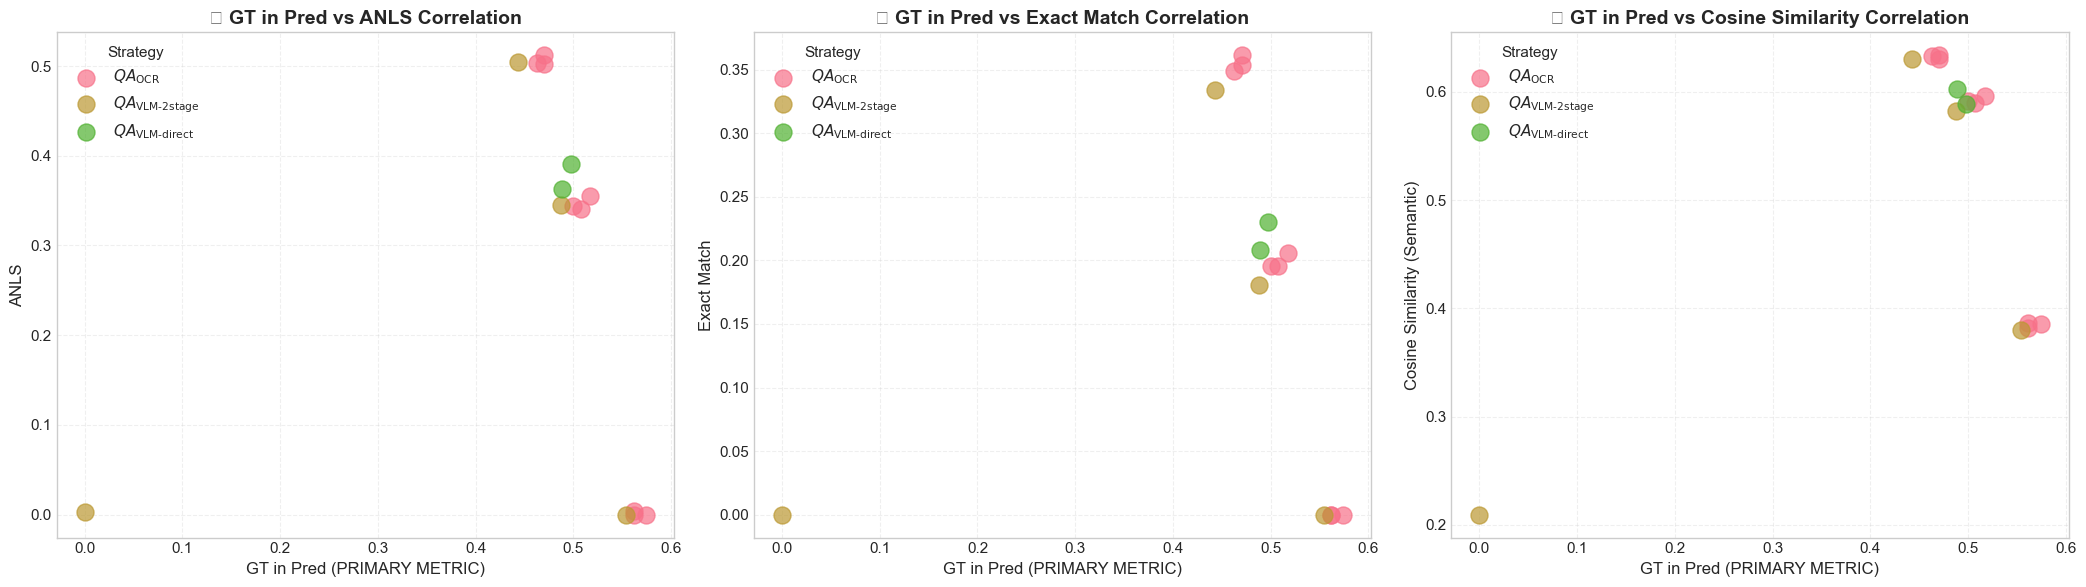


🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)


In [53]:
# Scatter plots: GT in Pred (PRIMARY) vs other metrics
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# GT in Pred vs ANLS
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['GT in Pred'], strategy_data['ANLS'],
                s=150, alpha=0.7, label=strategy)
ax1.set_title('🎯 GT in Pred vs ANLS Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax1.set_ylabel('ANLS', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Exact Match
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['GT in Pred'], strategy_data['Exact Match'],
                s=150, alpha=0.7, label=strategy)
ax2.set_title('🎯 GT in Pred vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax2.set_ylabel('Exact Match', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Cosine Similarity
ax3 = axes[2]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax3.scatter(strategy_data['GT in Pred'], strategy_data['Cosine Similarity'],
                s=150, alpha=0.7, label=strategy)
ax3.set_title('🎯 GT in Pred vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax3.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax3.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax3.legend(title='Strategy', loc='best')
ax3.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)")

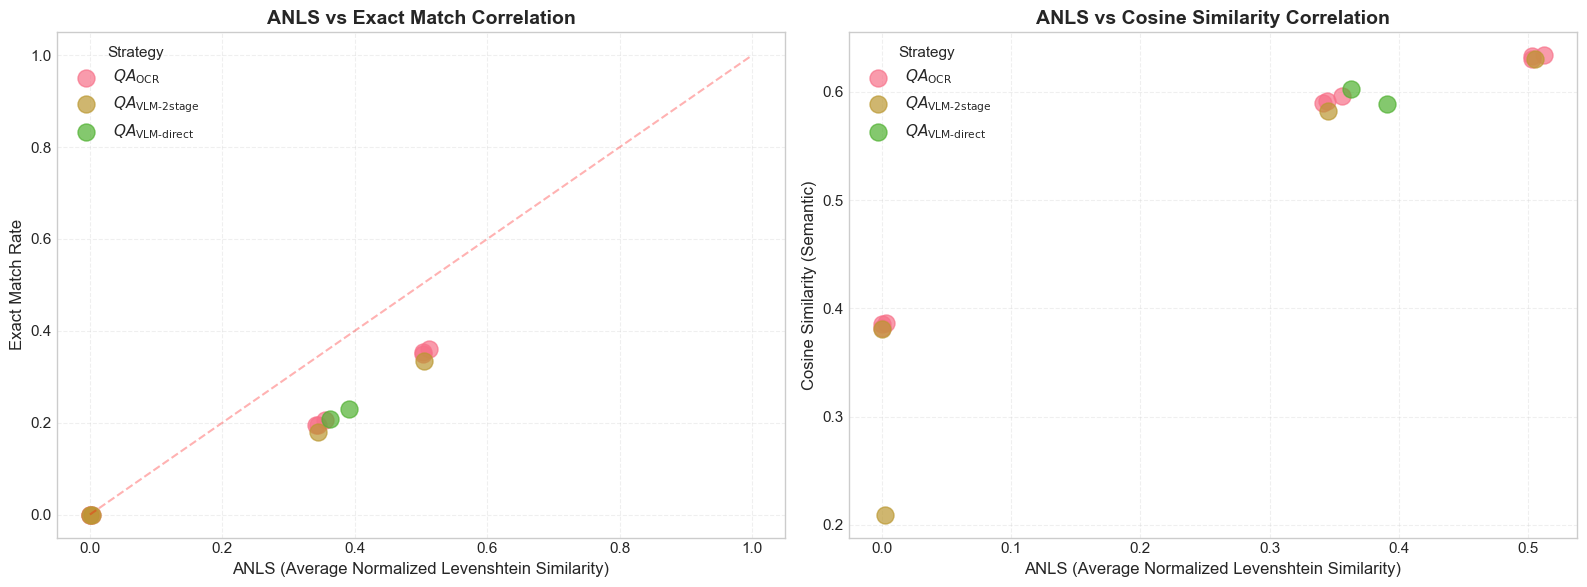

In [54]:
# Scatter plots: ANLS vs other metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ANLS vs Exact Match
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['ANLS'], strategy_data['Exact Match'],
                s=150, alpha=0.7, label=strategy)
ax1.set_title('ANLS vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax1.set_ylabel('Exact Match Rate', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')
ax1.plot([0, 1], [0, 1], 'r--', alpha=0.3, label='ANLS=EM')

# ANLS vs Cosine Similarity
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['ANLS'], strategy_data['Cosine Similarity'],
                s=150, alpha=0.7, label=strategy)
ax2.set_title('ANLS vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax2.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 10.5 Ground Truth in Parsed Data Analysis

Heatmap visualization for "Ground Truth in Parsed Data" metric across all experiments.



GROUND TRUTH IN PARSED DATA - Heatmap Analysis

This metric indicates the percentage of samples where the ground truth appears in the parsed/extracted data.
High values suggest the OCR/parsing step successfully extracted relevant information.


Ground Truth in Parsed Data - QA1 (OCR+VLM)

Ground Truth in Parsed Data - QA1 (OCR+VLM):


,QA1a,QA1b,QA1c
Mistral OCR 3 → GPT-5 Mini,NaN,NaN,NaN
Azure Intelligence → GPT-5 Mini,NaN,NaN,NaN
Mistral OCR 2 → GPT-5 Mini,NaN,NaN,NaN


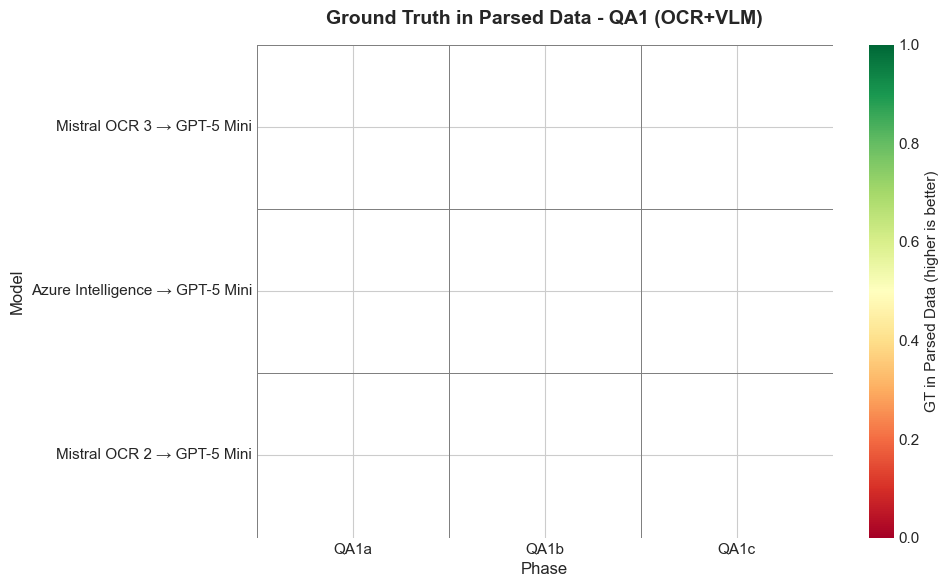


Ground Truth in Parsed Data - QA2 (VLM Parse+QA)

Ground Truth in Parsed Data - QA2 (VLM Parse+QA):


,QA2a,QA2b,QA2c
GPT-5 Mini → GPT-5 Mini,NaN,NaN,NaN
gpt-5-mini_gpt-5-mini,NaN,NaN,NaN
in_ground_truth_gpt-5-mini_gpt-5-mini,NaN,NaN,NaN


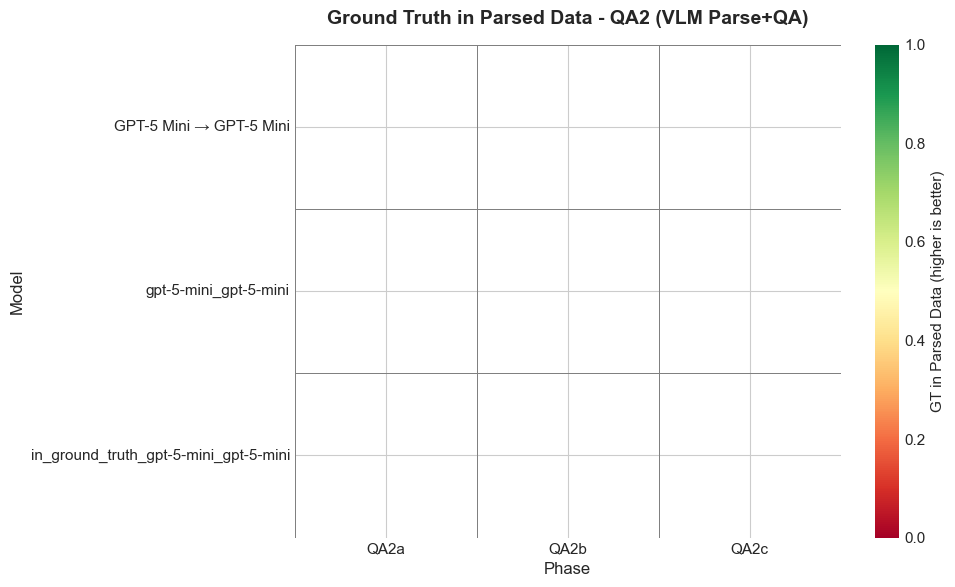


Ground Truth in Parsed Data - QA3 (Direct VQA)

Ground Truth in Parsed Data - QA3 (Direct VQA):


,QA3a,QA3b
GPT-5 Mini,NaN,NaN


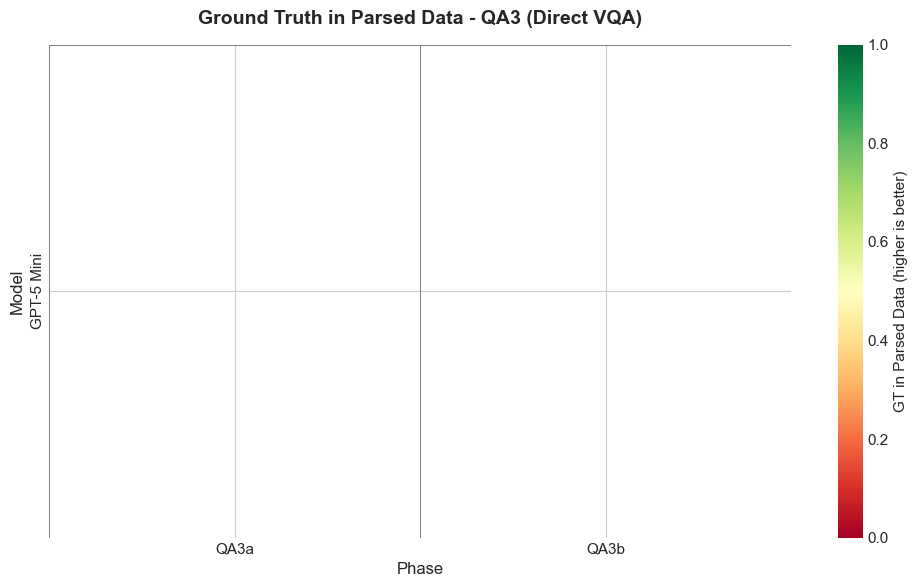

In [55]:
# Ground Truth in Parsed Data heatmap
print("\n" + "="*100)
print("GROUND TRUTH IN PARSED DATA - Heatmap Analysis")
print("="*100)
print("\nThis metric indicates the percentage of samples where the ground truth appears in the parsed/extracted data.")
print("High values suggest the OCR/parsing step successfully extracted relevant information.\n")

# Define strategies and their phases
strategy_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

for strategy_name, phases in strategy_groups.items():
    print(f"\n{'='*80}")
    print(f"Ground Truth in Parsed Data - {strategy_name}")
    print(f"{'='*80}")
    
    # Filter phases for this strategy
    strategy_phase_names = [p for p in phases if p in metrics_results]
    if not strategy_phase_names:
        print(f"⚠️ No phases found for {strategy_name}")
        continue
    
    # Create heatmap data: rows = models, columns = phases in this strategy
    heatmap_data = []
    model_names = []
    
    # Get all unique models across the phases in this strategy
    all_models = set()
    for phase in strategy_phase_names:
        if phase in metrics_results:
            all_models.update(metrics_results[phase].keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in strategy_phase_names:
            if phase in metrics_results and model in metrics_results[phase]:
                value = metrics_results[phase][model].get('gt_in_parsed', np.nan)
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[get_model_display_name(m) for m in model_names],
        columns=strategy_phase_names
    )
    
    # Print the table
    print(f"\nGround Truth in Parsed Data - {strategy_name}:")
    display(heatmap_df)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Use colormap: green for good, red for bad
    cmap = 'RdYlGn'
    cbar_label = 'GT in Parsed Data (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
    
    ax.set_title(f'Ground Truth in Parsed Data - {strategy_name}', 
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Phase', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*100)

## 11. QA-Specific Analysis

Analyze question types, answer lengths, and QA-specific patterns.


Question Type Distribution (QA1a):
  What           :  239 questions ( 59.2%)
  How            :   54 questions ( 13.4%)
  Yes/No         :   29 questions (  7.2%)
  Who            :   25 questions (  6.2%)
  Other          :   25 questions (  6.2%)
  Which          :   18 questions (  4.5%)
  When           :    9 questions (  2.2%)
  Where          :    5 questions (  1.2%)


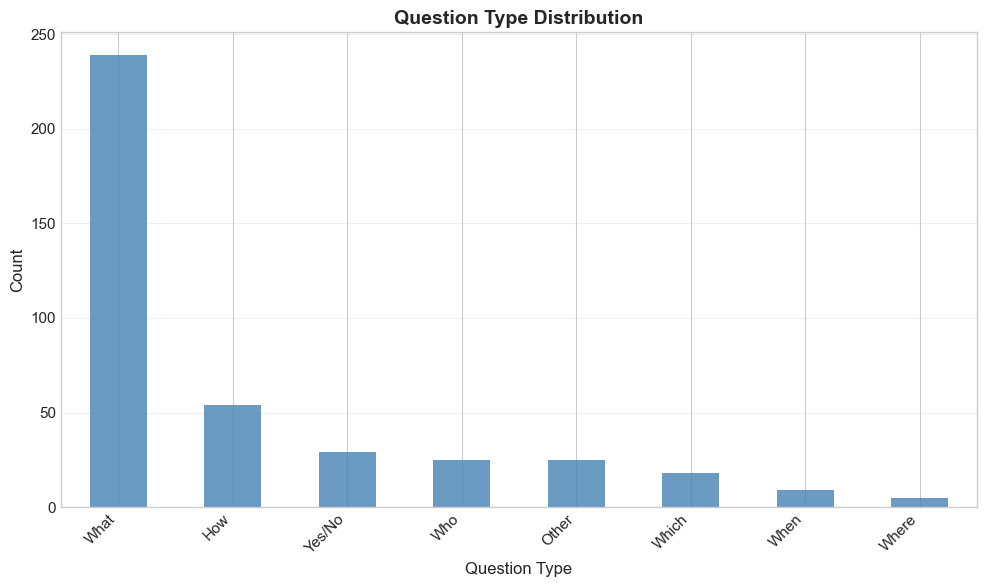

In [56]:
# Question type analysis
if len(phase_dfs) > 0:
    # Use first available phase for analysis
    analysis_phase = list(phase_dfs.keys())[0]
    df_analysis = phase_dfs[analysis_phase].copy()
    
    # Add question type categorization
    df_analysis['question_type'] = df_analysis['question'].apply(categorize_question_type)
    
    print(f"\nQuestion Type Distribution ({analysis_phase}):")
    print("=" * 80)
    type_counts = df_analysis['question_type'].value_counts()
    for qtype, count in type_counts.items():
        pct = count / len(df_analysis) * 100
        print(f"  {qtype:15s}: {count:4d} questions ({pct:5.1f}%)")
    
    # Visualize question types
    fig, ax = plt.subplots(figsize=(10, 6))
    type_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title('Question Type Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Type', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

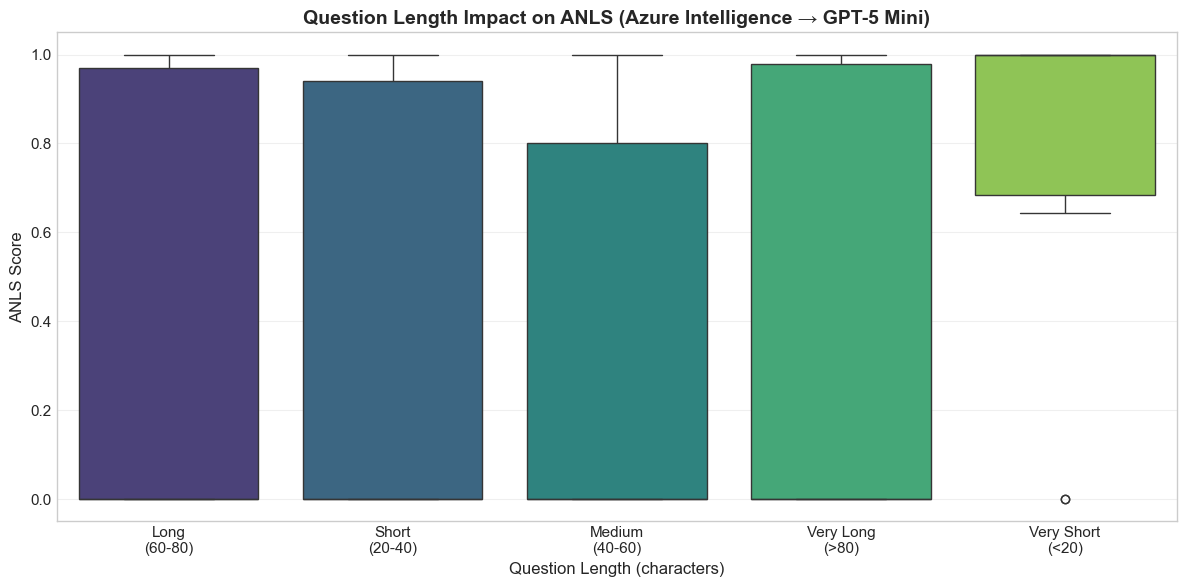

In [57]:
# Question length impact on performance
if len(phase_dfs) > 0:
    df_analysis['question_length'] = df_analysis['question'].astype(str).str.len()
    df_analysis['question_length_bin'] = pd.cut(
        df_analysis['question_length'],
        bins=[0, 20, 40, 60, 80, 1000],
        labels=['Very Short\n(<20)', 'Short\n(20-40)', 'Medium\n(40-60)', 'Long\n(60-80)', 'Very Long\n(>80)']
    )
    
    # Calculate ANLS for first model per length bin
    pred_col = [col for col in df_analysis.columns if col.startswith('prediction_')][0]
    model_name = pred_col.replace('prediction_', '')
    
    anls_by_length = []
    for _, row in df_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[pred_col]), ground_truths, threshold=0.5)
        anls_by_length.append({
            'question_length_bin': row['question_length_bin'],
            'anls': anls
        })
    
    anls_length_df = pd.DataFrame(anls_by_length)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=anls_length_df, x='question_length_bin', y='anls', ax=ax, palette='viridis')
    ax.set_title(f'Question Length Impact on ANLS ({get_model_display_name(model_name)})', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Length (characters)', fontsize=12)
    ax.set_ylabel('ANLS Score', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 12. Phase Comparison Analysis

Compare the three QA strategies: OCR+VLM, VLM Parse+QA, and Direct VQA.

In [58]:
strategy_results = []
for group_name, phases in phase_groups.items():
    # Filter by Phase column (QA1a, QA1b, etc.), not Strategy column
    group_data = summary_df[summary_df['Phase'].isin(phases)]
    if len(group_data) > 0:
        avg_gt_in_pred = group_data['GT in Pred'].mean()
        avg_anls = group_data['ANLS'].mean()
        avg_em = group_data['Exact Match'].mean()
        avg_substring = group_data['Substring Match'].mean()
        
        print(f"\n{group_name}:")
        print(f"  🎯 Mean GT in Pred: {avg_gt_in_pred:.4f} [PRIMARY]")
        print(f"     Mean ANLS: {avg_anls:.4f}")
        print(f"     Mean Exact Match: {avg_em:.4f}")
        print(f"     Mean Substring Match: {avg_substring:.4f}")
        print(f"  Phases included: {', '.join(phases)}")
        
        strategy_results.append({
            'Strategy': group_name,
            'GT in Pred': avg_gt_in_pred,  # PRIMARY FIRST
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Substring Match': avg_substring
        })
    else:
        print(f"\n⚠️ {group_name}: No data found for phases {phases}")

NameError: name 'phase_groups' is not defined

## 13. Sample-Level Error Analysis

Identify easiest and hardest questions to understand error patterns.

In [ ]:
# Analyze best and worst performing samples
if len(phase_dfs) > 0:
    analysis_phase = list(phase_dfs.keys())[0]
    df_error_analysis = phase_dfs[analysis_phase].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_error_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Calculate ANLS for each sample
    anls_scores = []
    for _, row in df_error_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[f'prediction_{first_model}']), ground_truths, threshold=0.5)
        anls_scores.append(anls)
    
    df_error_analysis['anls'] = anls_scores
    
    # Get best and worst samples
    best_samples = df_error_analysis.nlargest(10, 'anls')
    worst_samples = df_error_analysis.nsmallest(10, 'anls')
    
    print("\n" + "="*120)
    print(f"EASIEST QUESTIONS (Highest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in best_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")
    
    print("\n" + "="*120)
    print(f"HARDEST QUESTIONS (Lowest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in worst_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")


EASIEST QUESTIONS (Highest ANLS) - Model: Azure Intelligence → GPT-5 Mini

Sample: 06cc755612621483103dd1752c3927f7_20bc915e220e460a539fb622f1085943 | ANLS: 1.0000
Question: Who is the RIT Men's Hockey team playing against October 28?
Ground Truths: "Notre Dame"
Prediction: Notre Dame

Sample: 098bda18540fa5e097196c3f7898d4f1_c55543406c7e546faafb9246d0fff991 | ANLS: 1.0000
Question: How many people are there in the two pictures with the subtitle Taste Test on the first page?
Ground Truths: "4"
Prediction: 4

Sample: 09a039762a17ef85fbe52be984e62740_fbf54b9254d8e59ffb90f1972763545a | ANLS: 1.0000
Question: WHAT IS THE EXPAND OF ISS?
Ground Truths: "INTERNATIONAL SPACE STATION"
Prediction: International Space Station

Sample: 0afbb63ded89d3335a5109f8a9ec4db7_a19fd127268fb9493257f12d53d5d53d | ANLS: 1.0000
Question: According to the American Rescue Plan, what was the percentage of unemployment in New York prior to ...
Ground Truths: "3.9%"
Prediction: 3.9%

Sample: 0afbb63ded89d3335a5109

## 14. Inference Time Analysis

Analyze speed vs accuracy trade-offs.


Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms),Strategy
1,QA1a,mistral_document_ai__gpt-5-mini,10987.070182,9023.925185,QA1 (OCR+VLM)
0,QA1a,azure_intelligence__gpt-5-mini,14108.144354,11151.789546,QA1 (OCR+VLM)
3,QA1b,mistral_document_ai__gpt-5-mini,10457.573617,8888.805985,QA1 (OCR+VLM)
2,QA1b,azure_intelligence__gpt-5-mini,12987.485448,10167.797565,QA1 (OCR+VLM)
5,QA1c,mistral_document_ai__gpt-5-mini,13864.428838,12103.630424,QA1 (OCR+VLM)
4,QA1c,azure_intelligence__gpt-5-mini,17644.109300,11987.199903,QA1 (OCR+VLM)
6,QA2a,gpt-5-mini__gpt-5-mini,25036.871067,22526.462555,QA2 (VLM Parse+QA)
7,QA2b,gpt-5-mini__gpt-5-mini,23580.006194,21973.999977,QA2 (VLM Parse+QA)
8,QA2c,gpt-5-mini_gpt-5-mini,25521.843176,23721.717954,QA2 (VLM Parse+QA)
9,QA3a,gpt-5-mini,6892.738389,6021.960855,QA3 (Direct VQA)


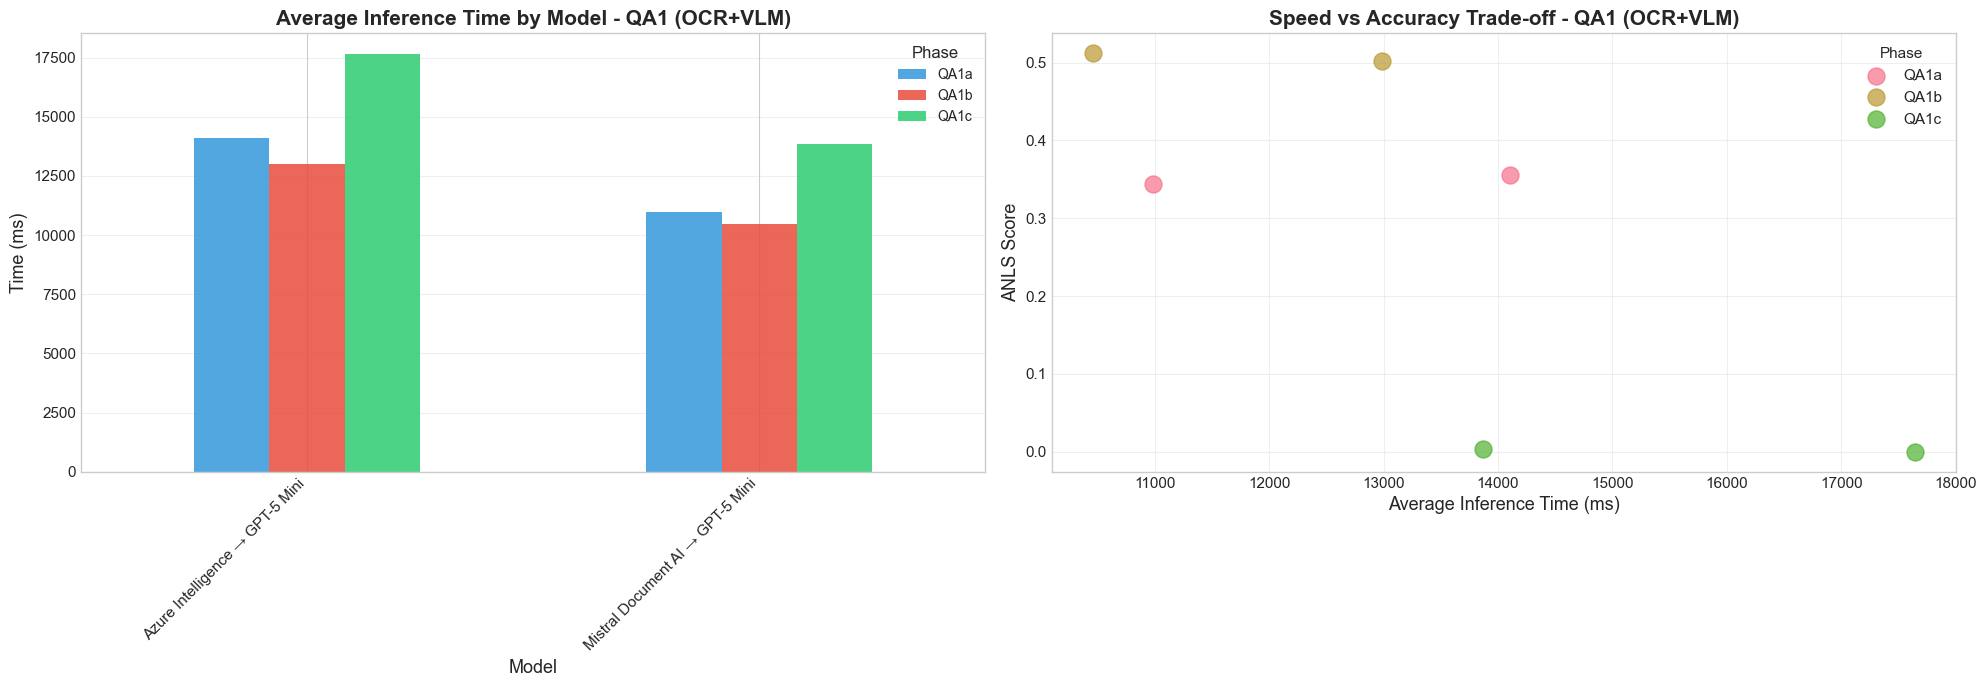

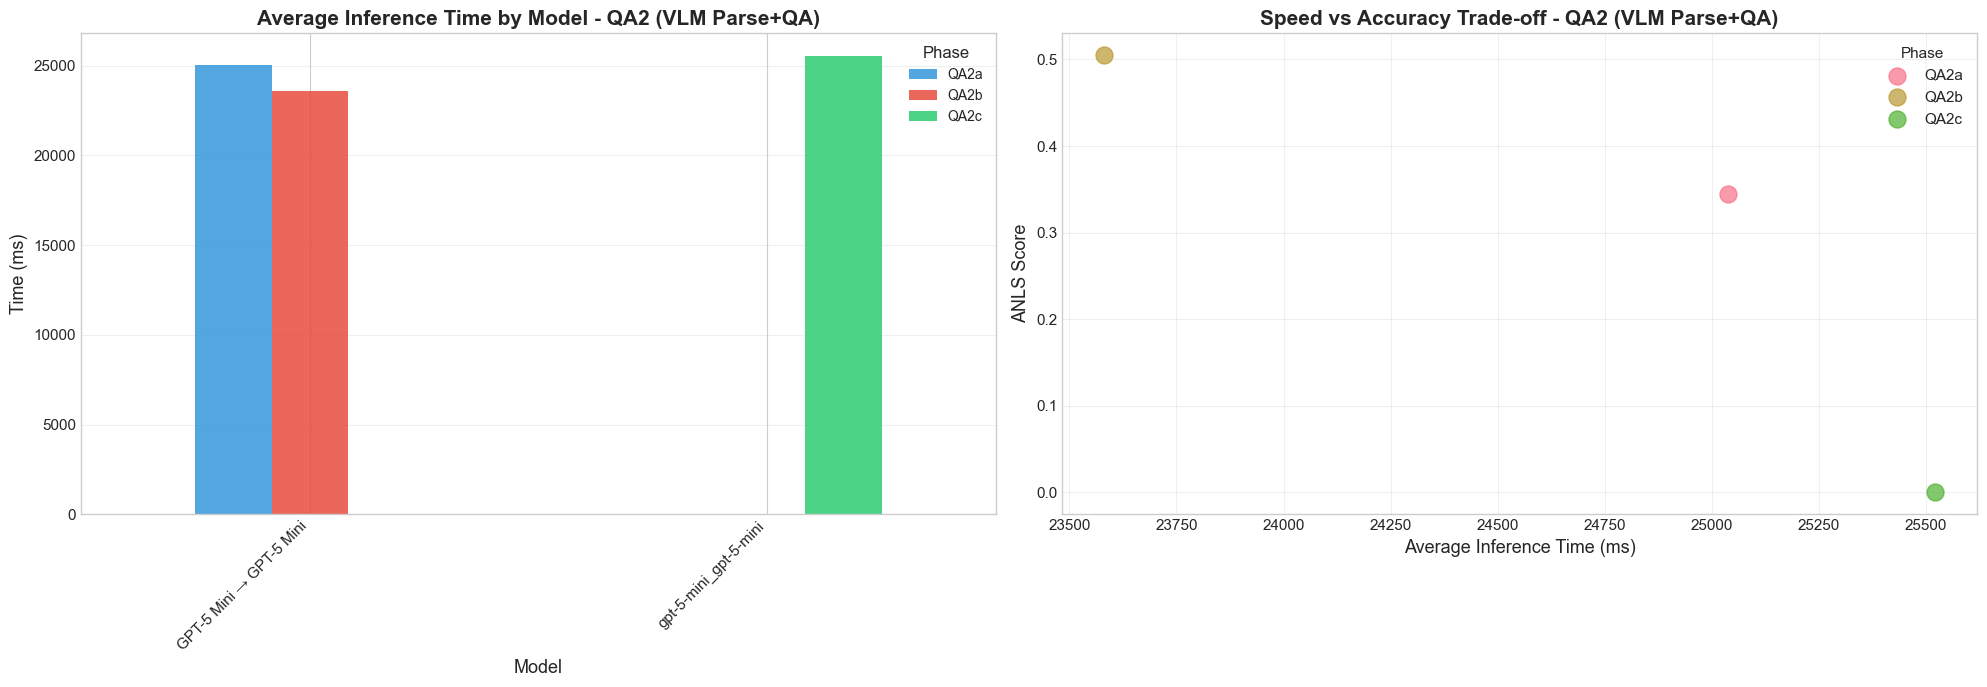

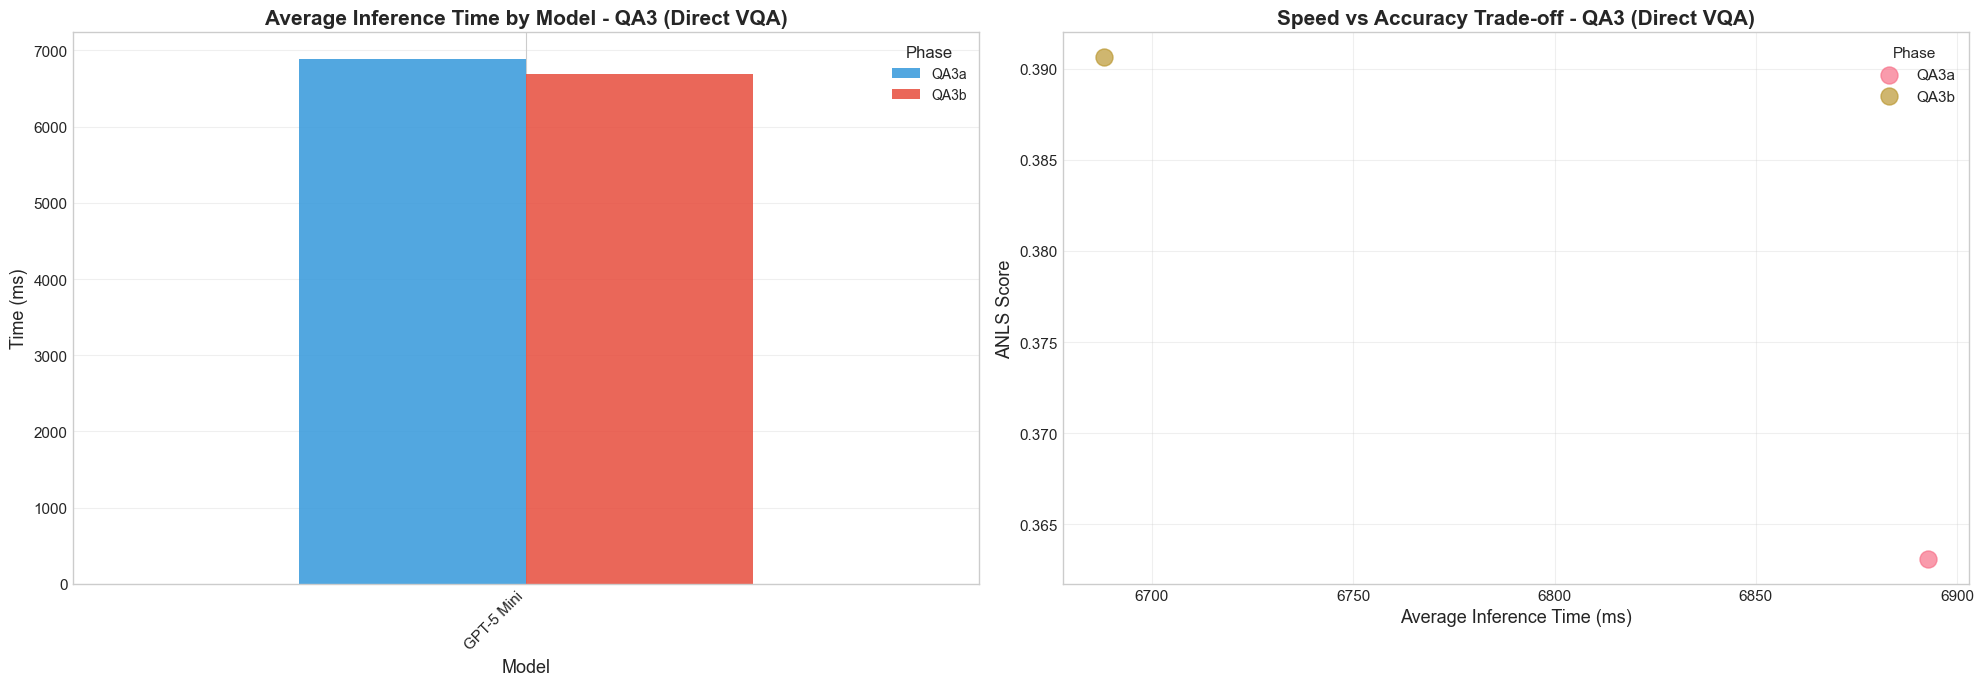

In [ ]:
# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Phase': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    inference_df['Strategy'] = inference_df['Phase'].apply(get_phase_strategy)
    
    print("\nInference Time Summary:")
    print("="*120)
    display(inference_df.sort_values(['Strategy', 'Phase', 'Mean Time (ms)']))
    
    # Define color palette
    colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']
    
    # Define strategies
    strategies = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']
    
    # Visualization: one graph per QA strategy
    for strategy in strategies:
        strategy_inference = inference_df[inference_df['Strategy'] == strategy]
        if strategy_inference.empty:
            continue
        
        fig, axes = plt.subplots(1, 2, figsize=(20, 7))
        
        # Bar chart for inference time
        ax1 = axes[0]
        pivot_time = strategy_inference.pivot(index='Model', columns='Phase', values='Mean Time (ms)')
        pivot_time = pivot_time.reindex(sort_models(pivot_time.index.tolist()))
        pivot_time.plot(kind='bar', ax=ax1, color=colors_palette[:len(pivot_time.columns)], alpha=0.85)
        
        ax1.set_title(f'Average Inference Time by Model - {strategy}', fontsize=15, fontweight='bold')
        ax1.set_xlabel('Model', fontsize=13)
        ax1.set_ylabel('Time (ms)', fontsize=13)
        ax1.legend(title='Phase', title_fontsize=12, fontsize=10, loc='best')
        ax1.grid(axis='y', alpha=0.3)
        ax1.set_xticklabels([get_model_display_name(t.get_text()) for t in ax1.get_xticklabels()], 
                           rotation=45, ha='right')
        
        # Speed vs Accuracy scatter plot
        ax2 = axes[1]
        
        # Merge inference time with ANLS scores for this strategy
        strategy_summary = summary_df[summary_df['Strategy'] == strategy]
        speed_accuracy = pd.merge(
            strategy_inference[['Phase', 'Model', 'Mean Time (ms)']],
            strategy_summary[['Phase', 'Model', 'ANLS']],
            on=['Phase', 'Model']
        )
        
        for phase in speed_accuracy['Phase'].unique():
            phase_data = speed_accuracy[speed_accuracy['Phase'] == phase]
            ax2.scatter(phase_data['Mean Time (ms)'], phase_data['ANLS'], 
                       s=150, alpha=0.7, label=phase)
        
        ax2.set_title(f'Speed vs Accuracy Trade-off - {strategy}', fontsize=15, fontweight='bold')
        ax2.set_xlabel('Average Inference Time (ms)', fontsize=13)
        ax2.set_ylabel('ANLS Score', fontsize=13)
        ax2.legend(title='Phase', loc='best')
        ax2.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("No inference time data available")

## 15. DUDE-Specific Analysis

Analyze DUDE dataset-specific patterns: document complexity, layout understanding, and multi-page reasoning.

In [ ]:
# Analyze performance on DUDE-specific challenges
print("\nDUDE-Specific Analysis:")
print("=" * 100)
print("\nDataset Characteristics:")
print("- DUDE (Document Understanding Dataset) focuses on complex, multi-page documents")
print("- Tests models on challenging real-world document scenarios")
print("- Requires reasoning across document layouts and structures")
print("- Evaluates multi-page reasoning capabilities")

print("\nKey Findings:")
print("- Complex document understanding requires both OCR accuracy and layout comprehension")
print("- Multi-page documents present unique challenges for context management")
print("- Structured document parsing benefits from specialized document AI models")

print("\nRecommendations:")
print("- For complex multi-page documents: Consider hybrid OCR+VLM approach (QA1)")
print("- For layout-heavy documents: VLM Parse+QA (QA2) can capture visual structure")
print("- For quick extraction: Direct VQA (QA3) may sacrifice accuracy for speed")
print("- Note: QA2c (Claude Sonnet) has large file size (56MB) - optimize memory if needed")

print("\nPerformance Patterns on Complex Documents:")
if len(summary_df) > 0:
    # Analyze which strategy works best for DUDE
    qa1_perf = summary_df[summary_df['Phase'].str.startswith('QA1')]['GT in Pred'].mean()
    qa2_perf = summary_df[summary_df['Phase'].str.startswith('QA2')]['GT in Pred'].mean()
    qa3_perf = summary_df[summary_df['Phase'].str.startswith('QA3')]['GT in Pred'].mean()
    
    print(f"  QA1 (OCR+VLM) average GT in Pred: {qa1_perf:.4f}")
    print(f"  QA2 (VLM Parse+QA) average GT in Pred: {qa2_perf:.4f}")
    print(f"  QA3 (Direct VQA) average GT in Pred: {qa3_perf:.4f}")
    
    best_strategy = max(
        [('QA1 (OCR+VLM)', qa1_perf), ('QA2 (VLM Parse+QA)', qa2_perf), ('QA3 (Direct VQA)', qa3_perf)],
        key=lambda x: x[1]
    )
    print(f"\n  🏆 Best performing strategy for DUDE: {best_strategy[0]} ({best_strategy[1]:.4f})")


DUDE-Specific Analysis:

Dataset Characteristics:
- DUDE (Document Understanding Dataset) focuses on complex, multi-page documents
- Tests models on challenging real-world document scenarios
- Requires reasoning across document layouts and structures
- Evaluates multi-page reasoning capabilities

Key Findings:
- Complex document understanding requires both OCR accuracy and layout comprehension
- Multi-page documents present unique challenges for context management
- Structured document parsing benefits from specialized document AI models

Recommendations:
- For complex multi-page documents: Consider hybrid OCR+VLM approach (QA1)
- For layout-heavy documents: VLM Parse+QA (QA2) can capture visual structure
- For quick extraction: Direct VQA (QA3) may sacrifice accuracy for speed
- Note: QA2c (Claude Sonnet) has large file size (56MB) - optimize memory if needed

Performance Patterns on Complex Documents:
  QA1 (OCR+VLM) average GT in Pred: 0.5136
  QA2 (VLM Parse+QA) average GT in Pred

## 17. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [ ]:
# Save any remaining embeddings to disk for future use
print("\n📁 Finalizing embedding cache...")

if embedding_manager.modified_phases:
    print(f"Saving embeddings for modified phases: {embedding_manager.modified_phases}")
    
    for phase in embedding_manager.modified_phases:
        if phase in embedding_manager.cache:
            saved_file = save_embeddings_for_phase(
                dataset_name=DATASET_NAME,
                phase=phase,
                embeddings_dict=embedding_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"✅ Saved: {saved_file.name}")
    
    print("\n✅ All embeddings have been persisted to disk!")
else:
    print("✅ No new embeddings to save (all from cache)")


📁 Finalizing embedding cache...
✅ No new embeddings to save (all from cache)
